# Visualization: Training Data Integration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from plotnine import *

In [3]:
save_dir = Path("../output/data/train_data_integration/visualization")
save_dir.mkdir(parents=True, exist_ok=True)

print(f"💾 Save results to: '{save_dir}'")

💾 Save results to: '../output/data/train_data_integration/visualization'


## Training Data

**Healthy:**  
[INFO] 2025-08-05 18:13:02 |> Range of counts: 0 - 3716

**NAFLD:**  
[INFO] 2025-08-05 17:53:17 |> Range of counts: 0 - 2715

These observed ranges indicate that no form of scaling or normalization was performed with these counts.
This is the raw data.

### Healthy Mouse Liver scRNA-seq

In [2]:
path_to_healthy = Path(
    "../output/data/train_data_integration/healthy_mouse_liver_scRNAseq"
)

In [3]:
healthy_sample_metrics_file = (
    path_to_healthy / "healthy_mouse_liver_scRNAseq_sample_metrics.feather"
)
healthy_sample_metrics = pd.read_feather(healthy_sample_metrics_file)
healthy_sample_metrics.head(5)

,counts,sparsity,annotation,umap_1,umap_2,cluster
AAACCTGAGAGCCCAA-1,2293,0.967089,pDCs,0.545411,-8.261642,9.0
AAACCTGAGCTAGTCT-1,2066,0.970663,Kupffer cells,-6.840581,3.870898,0.0
AAACCTGAGTTCGCGC-1,1013,0.984768,T cells,10.199693,-7.500118,21.0
AAACCTGCAACACCCG-1,2209,0.966992,pDCs,0.935696,-8.487344,9.0
AAACCTGCATAGGATA-1,5290,0.948057,Monocytes & Monocyte-derived cells,6.846276,3.955263,37.0


In [4]:
healthy_sample_metrics["counts"].max()

97546

In [5]:
healthy_gene_metrics_file = (
    path_to_healthy / "healthy_mouse_liver_scRNAseq_gene_metrics.feather"
)
healthy_gene_metrics = pd.read_feather(healthy_gene_metrics_file)
healthy_gene_metrics.head(5)

,counts,sparsity
Xkr4,2333,0.995347
Gm1992,21,0.999887
Gm37381,12,0.999935
Rp1,269,0.998687
Sox17,31926,0.891062


## NAFLD Mouse Liver scRNA-seq

In [6]:
path_to_nafld = Path("../output/data/train_data_integration/NAFLD_mouse_liver_scRNAseq")

In [7]:
nafld_sample_metrics_file = (
    path_to_nafld / "NAFLD_mouse_liver_scRNAseq_sample_metrics.feather"
)
nafld_sample_metrics = pd.read_feather(nafld_sample_metrics_file)
nafld_sample_metrics.head(5)

,counts,sparsity,annotation,umap_1,umap_2,cluster
AAACCTGAGCTGGAAC-1,4448,0.946414,KCs,11.771327,0.460150,0.0
AAACCTGAGGAGTTGC-1,3370,0.958426,KCs,12.302879,0.925721,0.0
AAACCTGAGTAGCCGA-1,5395,0.942260,Mono/mono-derived cells,7.537103,2.072303,12.0
AAACCTGAGTTAACGA-1,4196,0.946672,KCs,12.582746,0.548599,0.0
AAACCTGCAAGGTTTC-1,1524,0.973272,KCs,12.870411,1.093177,0.0


In [8]:
nafld_sample_metrics["counts"].max()

44650

In [9]:
nafld_gene_metrics_file = (
    path_to_nafld / "NAFLD_mouse_liver_scRNAseq_gene_metrics.feather"
)
nafld_gene_metrics = pd.read_feather(nafld_gene_metrics_file)
nafld_gene_metrics.head(5)

,counts,sparsity
Xkr4,401,0.997573
Gm1992,3,0.999975
Gm37381,7,0.999943
Rp1,140,0.998926
Sox17,5539,0.962559


## Visualization

### Count Distribution per Sample

In [10]:
healthy_sample_counts = healthy_sample_metrics[["counts"]].copy()
healthy_sample_counts["Dataset"] = "Healthy"

nafld_sample_counts = nafld_sample_metrics[["counts"]].copy()
nafld_sample_counts["Dataset"] = "NAFLD"

sample_counts = pd.concat([healthy_sample_counts, nafld_sample_counts])

sample_counts.to_feather(save_dir / "pdata_train_sample_counts.feather")
sample_counts.head(5)

,counts,Dataset
AAACCTGAGAGCCCAA-1,2293,Healthy
AAACCTGAGCTAGTCT-1,2066,Healthy
AAACCTGAGTTCGCGC-1,1013,Healthy
AAACCTGCAACACCCG-1,2209,Healthy
AAACCTGCATAGGATA-1,5290,Healthy


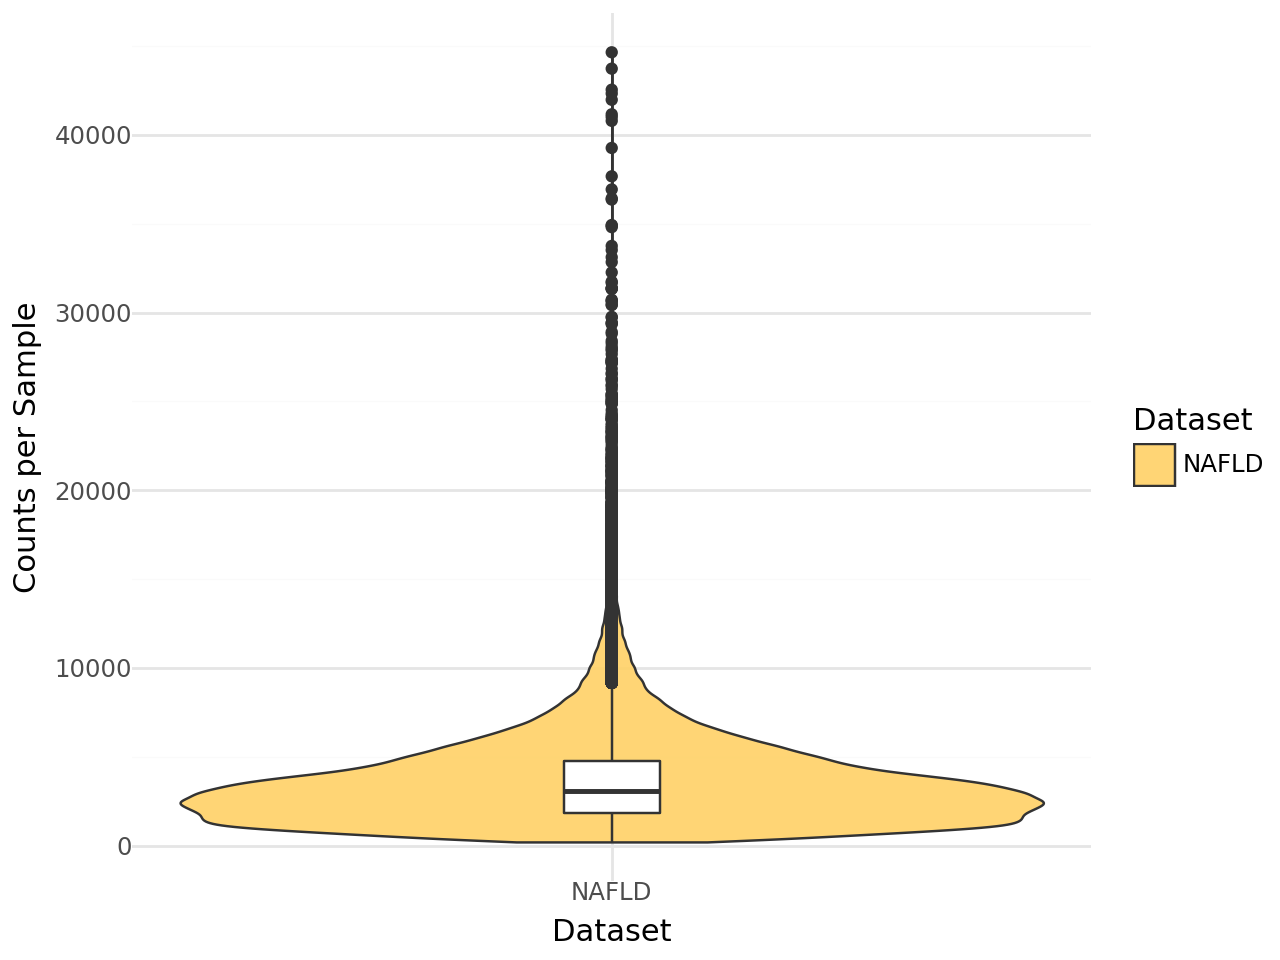

In [11]:
plot = (
    ggplot(sample_counts, aes(x="Dataset", y="counts", fill="Dataset"))
    + geom_violin(position="dodge", alpha=0.9)
    + geom_boxplot(width=0.1, fill="#ffffff")
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(y="Counts per Sample")
    + theme_minimal()
    + theme(plot_background=element_rect(fill="#ffffff", color="#ffffff"))
)

ggsave(plot, filename=save_dir / "train_sample_count_dists.png")

plot

### Count Distribution per Gene

In [26]:
healthy_gene_counts = healthy_gene_metrics[["counts"]].copy()
healthy_gene_counts["Dataset"] = "Healthy"

nafld_gene_counts = nafld_gene_metrics[["counts"]].copy()
nafld_gene_counts["Dataset"] = "NAFLD"

gene_counts = pd.concat([healthy_gene_counts, nafld_gene_counts])

# Log scale counts for more visual plots
gene_counts.counts = np.log10(gene_counts.counts + 1)

gene_counts.to_feather(save_dir / "pdata_train_gene_counts.feather")
gene_counts.head(5)

,counts,Dataset
Xkr4,3.368101,Healthy
Gm1992,1.342423,Healthy
Gm37381,1.113943,Healthy
Rp1,2.431364,Healthy
Sox17,4.504158,Healthy


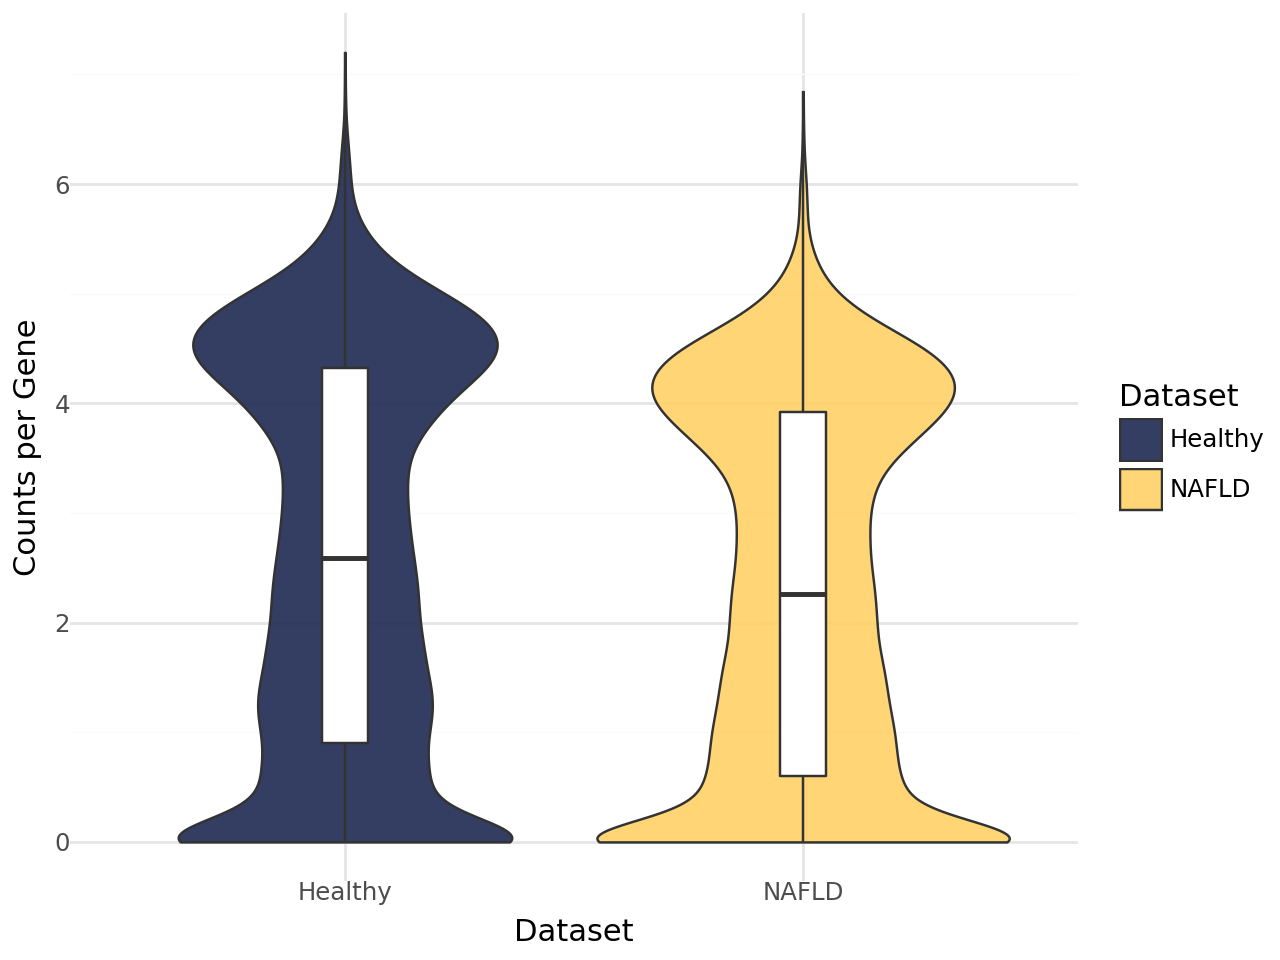

In [27]:
plot = (
    ggplot(gene_counts, aes(x="Dataset", y="counts", fill="Dataset"))
    + geom_violin(position="dodge", alpha=0.9)
    + geom_boxplot(width=0.1, fill="#ffffff")
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(y="Counts per Gene")
    + theme_minimal()
    + theme(plot_background=element_rect(fill="#ffffff", color="#ffffff"))
)

ggsave(plot, filename=save_dir / "train_gene_count_dists.png")

plot

### Sparsity Over Samples

In [38]:
healthy_sample_sparsity = healthy_sample_metrics[["sparsity"]].copy()
healthy_sample_sparsity["Dataset"] = "Healthy"

nafld_sample_sparsity = nafld_sample_metrics[["sparsity"]].copy()
nafld_sample_sparsity["Dataset"] = "NAFLD"

sample_sparsity = pd.concat([healthy_sample_sparsity, nafld_sample_sparsity])
sample_sparsity.head(5)

,sparsity,Dataset
AAACCTGAGAGCCCAA-1,0.967089,Healthy
AAACCTGAGCTAGTCT-1,0.970663,Healthy
AAACCTGAGTTCGCGC-1,0.984768,Healthy
AAACCTGCAACACCCG-1,0.966992,Healthy
AAACCTGCATAGGATA-1,0.948057,Healthy


In [39]:
# Define sparsity bins
sp_bins = [0, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0]
sp_labels = ["<50%", "50-80%", "80-90%", "90-95%", "95-99%", ">99%"]

results: list[dict] = []
for dataset in sample_sparsity["Dataset"].unique():
    subset = sample_sparsity[sample_sparsity["Dataset"] == dataset]
    subset_sparsity = subset["sparsity"].values

    counts, _ = np.histogram(subset_sparsity, bins=sp_bins)
    percentages = (counts / len(subset_sparsity)) * 100

    for i, label in enumerate(sp_labels):
        results.append(
            {
                "Dataset": dataset,
                "sparsity_range": label,
                "count": counts[i],
                "percentage": percentages[i],
            }
        )

custom_sample_sparsity = pd.DataFrame(results)
custom_sample_sparsity["sparsity_range"] = pd.Categorical(
    custom_sample_sparsity["sparsity_range"], categories=sp_labels, ordered=True
)

custom_sample_sparsity.to_feather(save_dir / "pdata_train_sample_sparsity.feather")
custom_sample_sparsity.head(5)

,Dataset,sparsity_range,count,percentage
0,Healthy,<50%,0,0.000000
1,Healthy,50-80%,339,0.182362
2,Healthy,80-90%,27159,14.609939
3,Healthy,90-95%,93123,50.094678
4,Healthy,95-99%,65232,35.090966


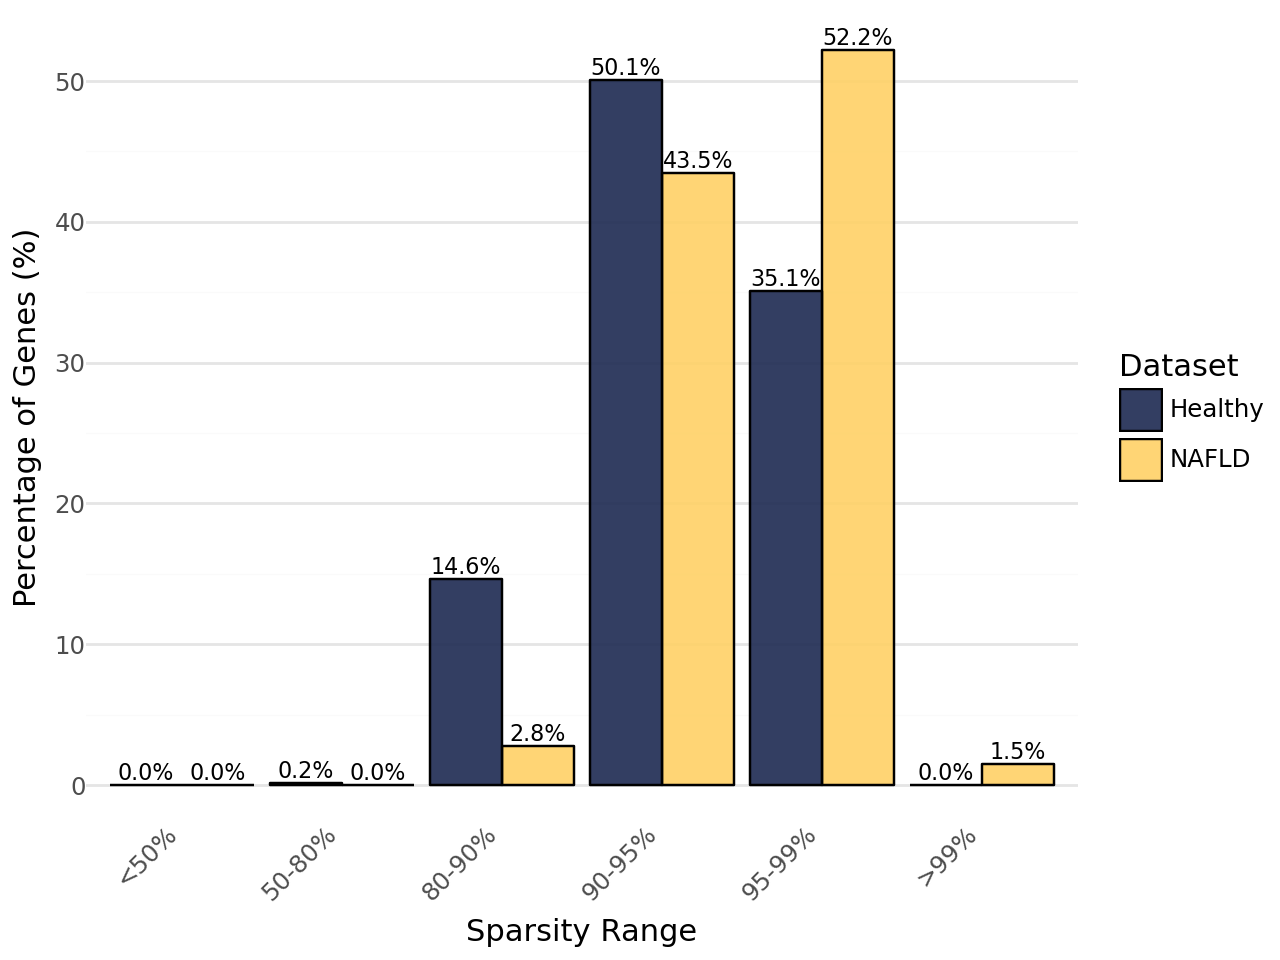

In [40]:
plot = (
    ggplot(
        custom_sample_sparsity, aes(x="sparsity_range", y="percentage", fill="Dataset")
    )
    + geom_col(position="dodge", alpha=0.9, color="#000000")
    + geom_text(
        aes(label="percentage"),
        format_string="{:.1f}%",
        position=position_dodge(width=0.9),
        va="bottom",
        size=8,
    )
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(x="Sparsity Range", y="Percentage of Genes (%)")
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major_x=element_blank(),
        axis_text_x=element_text(angle=45, hjust=1),
    )
)

ggsave(plot, filename=save_dir / "train_sample_sparsity.png")

plot

### Sparsity Over Genes

In [15]:
healthy_gene_sparsity = healthy_gene_metrics[["sparsity"]].copy()
healthy_gene_sparsity["Dataset"] = "Healthy"

nafld_gene_sparsity = nafld_gene_metrics[["sparsity"]].copy()
nafld_gene_sparsity["Dataset"] = "NAFLD"

gene_sparsity = pd.concat([healthy_gene_sparsity, nafld_gene_sparsity])
gene_sparsity.head(5)

,sparsity,Dataset
Xkr4,0.995347,Healthy
Gm1992,0.999887,Healthy
Gm37381,0.999935,Healthy
Rp1,0.998687,Healthy
Sox17,0.891062,Healthy


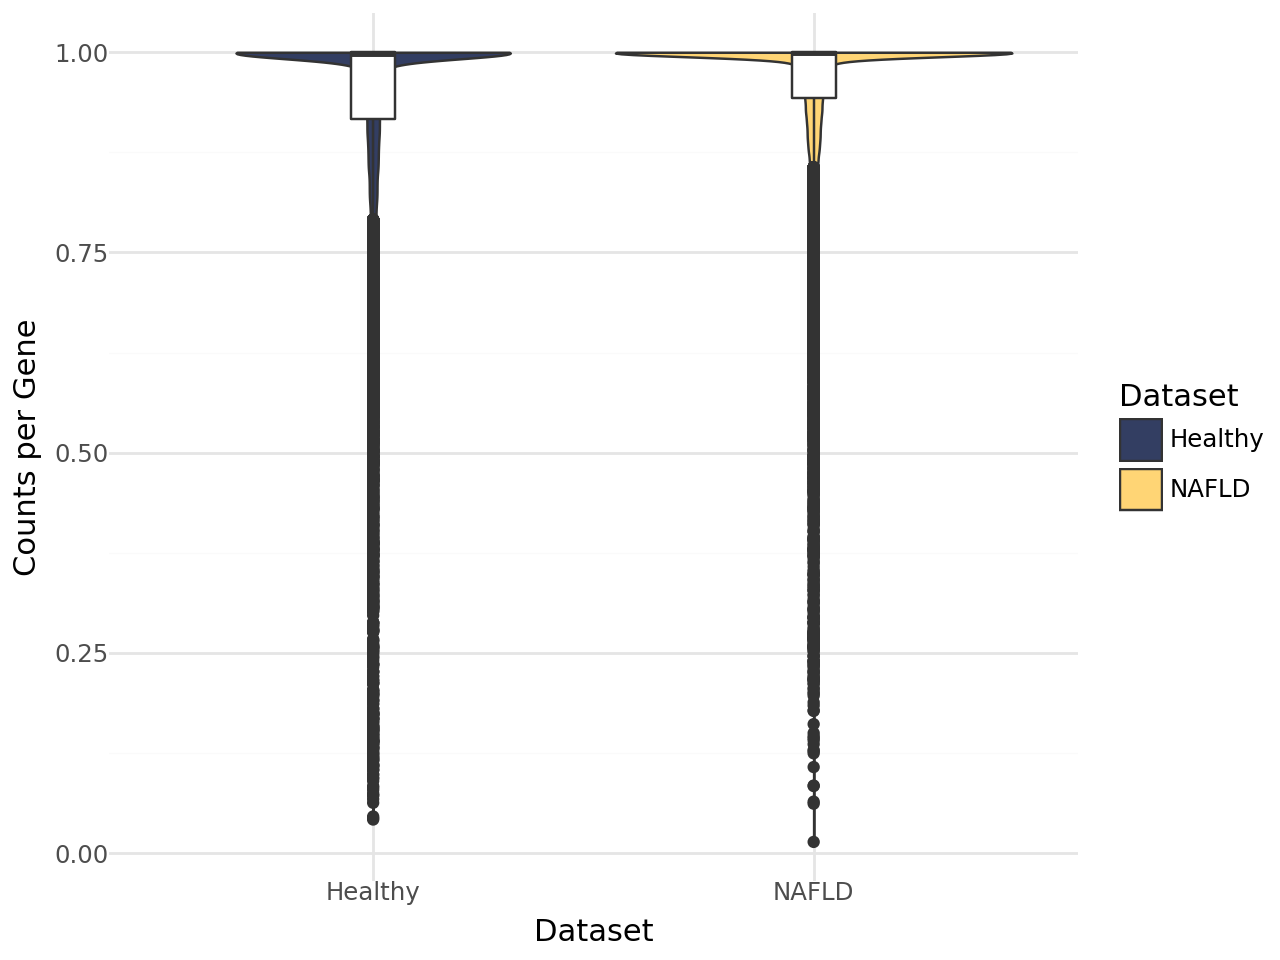

In [11]:
(
    ggplot(gene_sparsity, aes(x="Dataset", y="sparsity", fill="Dataset"))
    + geom_violin(position="dodge", alpha=0.9)
    + geom_boxplot(width=0.1, fill="#ffffff")
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(y="Counts per Gene")
    + theme_minimal()
    + theme(plot_background=element_rect(fill="#ffffff", color="#ffffff"))
)

In [28]:
# Define sparsity bins
sp_bins = [0, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0]
sp_labels = ["<50%", "50-80%", "80-90%", "90-95%", "95-99%", ">99%"]

results: list[dict] = []
for dataset in gene_sparsity["Dataset"].unique():
    subset = gene_sparsity[gene_sparsity["Dataset"] == dataset]
    subset_sparsity = subset["sparsity"].values

    counts, _ = np.histogram(subset_sparsity, bins=sp_bins)
    percentages = (counts / len(subset_sparsity)) * 100

    for i, label in enumerate(sp_labels):
        results.append(
            {
                "Dataset": dataset,
                "sparsity_range": label,
                "count": counts[i],
                "percentage": percentages[i],
            }
        )

custom_gene_sparsity = pd.DataFrame(results)
custom_gene_sparsity["sparsity_range"] = pd.Categorical(
    custom_gene_sparsity["sparsity_range"], categories=sp_labels, ordered=True
)

custom_gene_sparsity.to_feather(save_dir / "pdata_train_gene_sparsity.feather")
custom_gene_sparsity.head(5)

,Dataset,sparsity_range,count,percentage
0,Healthy,<50%,548,1.764725
1,Healthy,50-80%,3094,9.963611
2,Healthy,80-90%,3350,10.788008
3,Healthy,90-95%,2513,8.092616
4,Healthy,95-99%,3146,10.131066


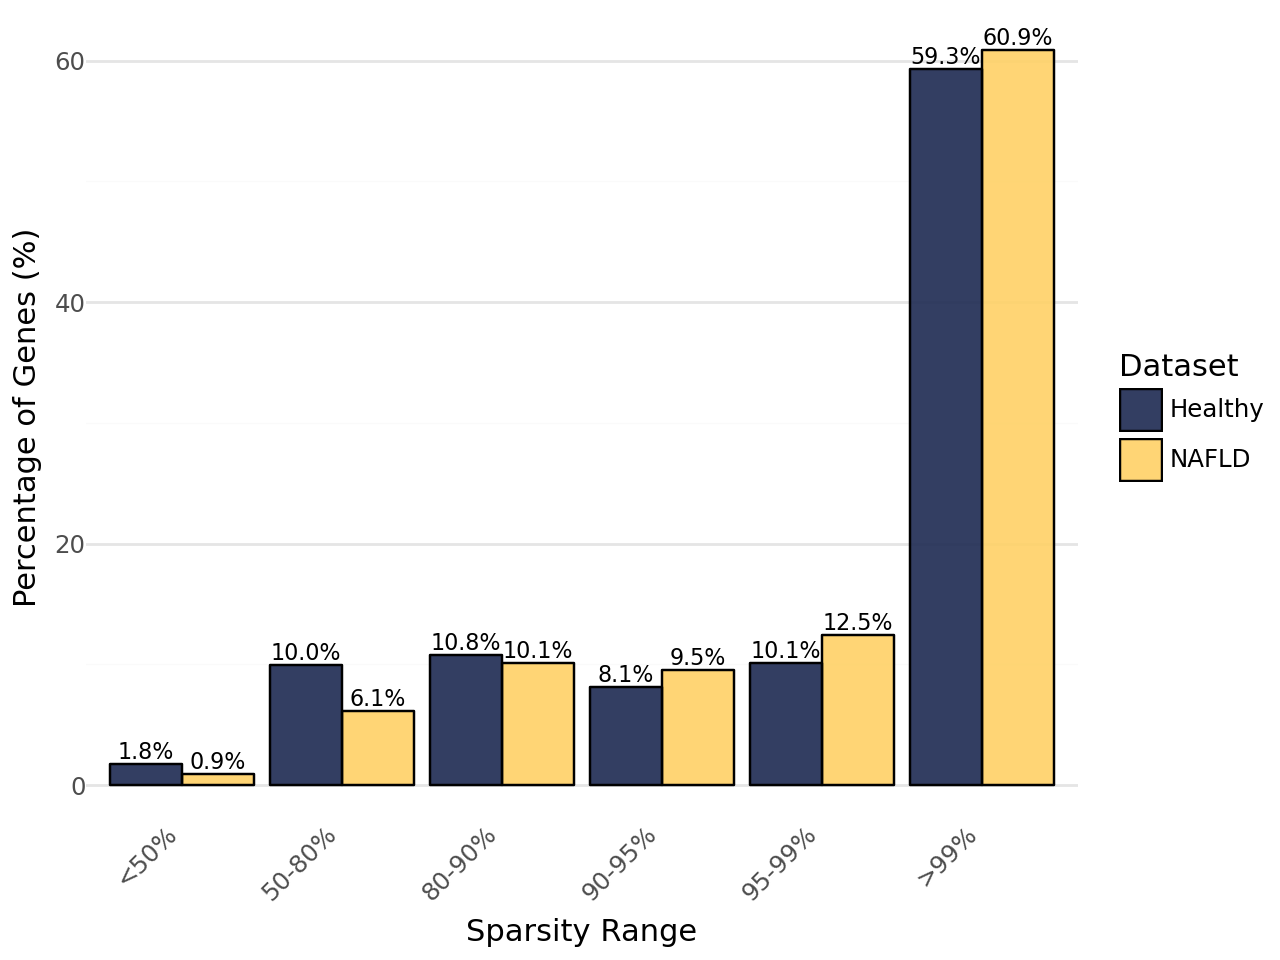

In [36]:
plot = (
    ggplot(
        custom_gene_sparsity, aes(x="sparsity_range", y="percentage", fill="Dataset")
    )
    + geom_col(position="dodge", alpha=0.9, color="#000000")
    + geom_text(
        aes(label="percentage"),
        format_string="{:.1f}%",
        position=position_dodge(width=0.9),
        va="bottom",
        size=8,
    )
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(x="Sparsity Range", y="Percentage of Genes (%)")
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        panel_grid_major_x=element_blank(),
        axis_text_x=element_text(angle=45, hjust=1),
    )
)

ggsave(plot, filename=save_dir / "train_gene_sparsity.png")

plot

### Cell Type Distribution

In [29]:
healthy_cell_types = healthy_sample_metrics[["annotation"]].copy()
healthy_cell_types = healthy_cell_types.value_counts().reset_index()
healthy_cell_types["Dataset"] = "Healthy"

nafld_cell_types = nafld_sample_metrics[["annotation"]].copy()
nafld_cell_types = nafld_cell_types.value_counts().reset_index()
nafld_cell_types["Dataset"] = "NAFLD"

cell_types = pd.concat([healthy_cell_types, nafld_cell_types])
cell_types = cell_types.reset_index()[["Dataset", "annotation", "count"]]
cell_types["percentage"] = cell_types.groupby("Dataset")["count"].transform(
    lambda x: x / x.sum() * 100
)

cell_types.to_feather(save_dir / "pdata_cell_types.feather")
cell_types.head(5)

,Dataset,annotation,count,percentage
0,Healthy,Endothelial cells,50194,27.001409
1,Healthy,Kupffer cells,39311,21.146998
2,Healthy,Hepatocytes,25908,13.936975
3,Healthy,Monocytes & Monocyte-derived cells,20712,11.141834
4,Healthy,T cells,9912,5.332071


/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: ../output/data/train_data_integration/visualization/train_cell_types.svg


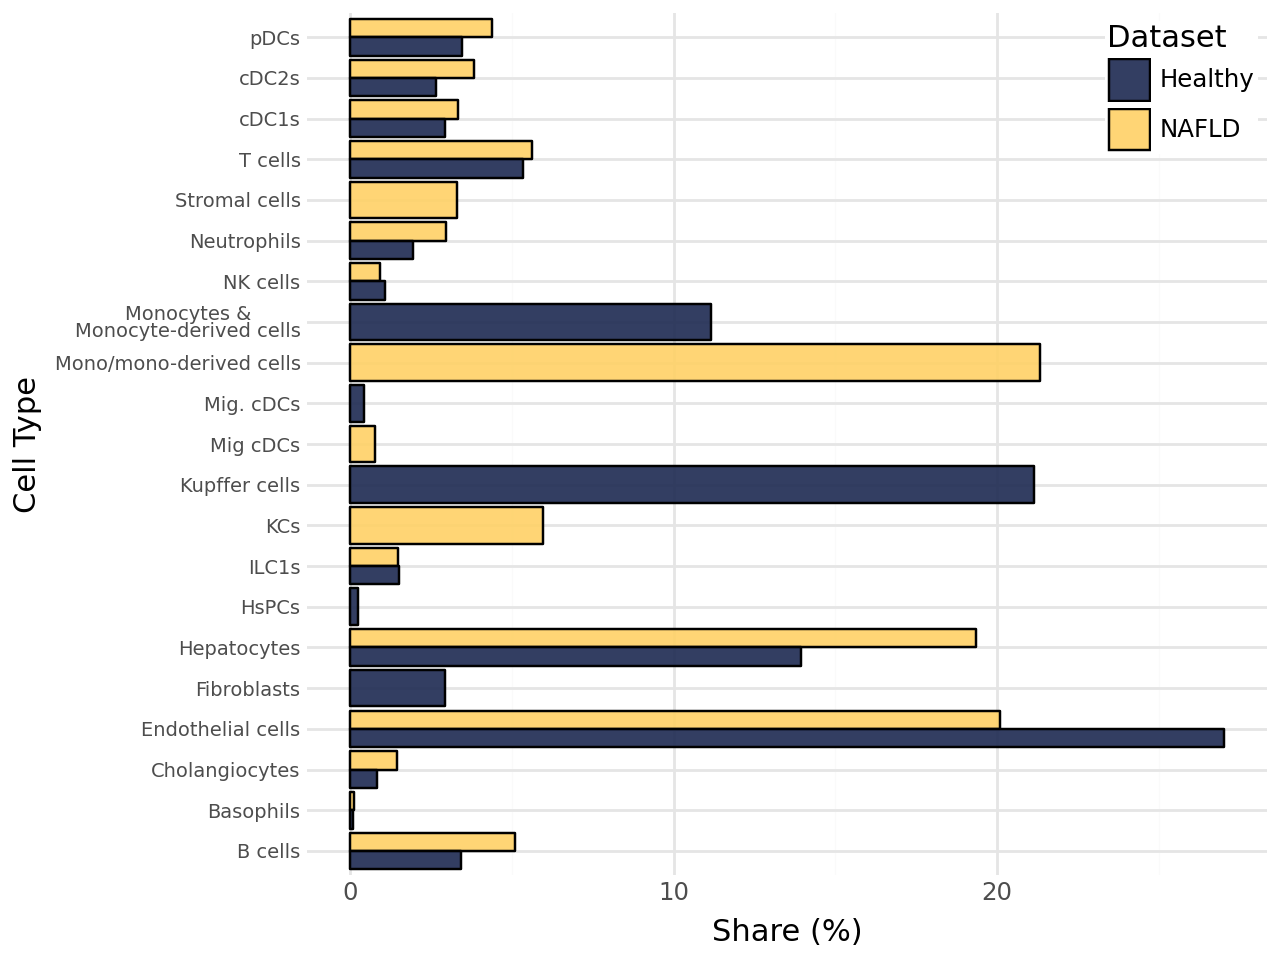

In [14]:
plot = (
    ggplot(cell_types, aes(x="annotation", y="percentage", fill="Dataset"))
    + geom_col(position="dodge", alpha=0.9, color="black")
    + coord_flip()
    + scale_fill_manual(values=["#1D2951", "#FFD166"])
    + labs(x="Cell Type", y="Share (%)")
    + theme_minimal()
    + theme(
        plot_background=element_rect(fill="#ffffff", color="#ffffff"),
        legend_position=(0.99, 0.99),
        legend_justification=(1, 1),
        legend_background=element_rect(fill="white", color="none"),
        axis_text_y=element_text(size=7),
    )
)

plot.save(save_dir / "train_cell_types.svg", dpi=300)
plot